In [25]:
import random  # библиотека функций для генерации случайных значений
# Сторонние библиотеки
import numpy as np  # библиотека функций для работы с матрицами

""" ---Раздел описаний--- """
""" --Описание класса Network--"""


class Network(object):  # используется для описания нейронной сети
    def __init__(self, sizes):  # конструктор класса
        # self – указатель на объект класса
        # sizes – список размеров слоев нейронной сети
        self.num_layers = len(sizes)  # задаем количество слоев нейронной сети
        self.sizes = sizes  # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]  # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in
                        zip(sizes[:-1], sizes[1:])]  # задаем случайные начальные веса связей

    def sigmoid(self, z):  # определение сигмоидальной функции активации
        return 1.0 / (1.0 + np.exp(-z))

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a) + b)
        return a

    def SGD(  # Стохастический градиентный спуск
            self  # указатель на объект класса
            , training_data  # обучающая выборка
            , epochs  # количество эпох обучения
            , mini_batch_size  # размер подвыборки
            , eta  # скорость обучения
            , test_data  # тестирующая выборка
    ):
        test_data = list(test_data)  # создаем список объектов тестирующей выборки
        n_test = len(test_data)  # вычисляем длину тестирующей выборки
        training_data = list(training_data)  # создаем список объектов обучающей выборки
        n = len(training_data)  # вычисляем размер обучающей выборки
        for j in range(epochs):  # цикл по эпохам
            random.shuffle(training_data)  # перемешиваем элементы обучающей выборки
            mini_batches = [training_data[k:k + mini_batch_size] for k in
                            range(0, n, mini_batch_size)]  # создаем подвыборки
            for mini_batch in mini_batches:  # цикл по подвыборкам
                #print(len(mini_batch[0][0]))
                self.update_mini_batch(mini_batch, eta)  # один шаг градиентного спуска
            print("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), n_test))  # смотрим прогресс в обучении

    def update_mini_batch(  # Шаг градиентного спуска
            self  # указатель на объект класса
            , mini_batch  # подвыборка
            , eta  # скорость обучения
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x,
                                                         y)  # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b,
                                                   delta_nabla_b)]  # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w,
                                                   delta_nabla_w)]  # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w - (eta / len(mini_batch)) * nw for w, nw in
                        zip(self.weights, nabla_w)]  # обновляем все веса w нейронной сети
        self.biases = [b - (eta / len(mini_batch)) * nb for b, nb in
                       zip(self.biases, nabla_b)]  # обновляем все смещения b нейронной сети

    def backprop(  # Алгоритм обратного распространения
            self  # указатель на объект класса
            , x  # вектор входных сигналов ,
            , y  # ожидаемый вектор выходных сигналов
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x  # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [
            x]  # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = []  # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b  # считаем активационные потенциалы текущего слоя
            zs.append(z)  # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(
                z)  # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation)  # добавляем элемент (выходные сигналы слоя) в конец списка
        # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(
            zs[-1])  # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta  # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())  # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
            z = zs[-l]  # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
            sp = self.sigmoid_prime(z)  # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
            delta = np.dot(self.weights[-l + 1].transpose(),
                           delta) * sp  # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
            nabla_b[-l] = delta  # градиент dC/db для l-го слоя (BP3)
            nabla_w[-l] = np.dot(delta, activations[-l - 1].transpose())  # градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):  # Оценка прогресса в обучении
        test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations,
                        y):  # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
        return (output_activations - y)

    def sigmoid_prime(self, z):  # Производная сигмоидальной функции
        return self.sigmoid(z) * (1 - self.sigmoid(z))

# """ --Конец описания класса Network--"""
# """ --- Конец раздела описаний--- """
# """ ---Тело программы--- """ 
# net = Network([2, 3, 1]) # создаем нейронную сеть из трех слоев 
# """---Конец тела программы--- """
# """ Вывод результата на экран: """ 
# print('Сеть net:') 
# print('Количетво слоев:', net.num_layers) 
# for i in range(net.num_layers): 
#     print('Количество нейронов в слое', i,':',net.sizes[i]) 
# for i in range(net.num_layers-1): 
#     print('W_',i+1,':') 
#     print(np.round(net.weights[i],2)) 
#     print('b_',i+1,':') 
#     print(np.round(net.biases[i],2))


In [26]:
import gzip  # библиотека для сжатия и распаковки файлов gzip и gunzip.
import pickle  # библиотека для сохранения и загрузки сложных объектов Python.
import numpy as np  # библиотека для работы с матрицами


# def load_data():
#   #f = gzip.open('mnist.pkl.gz', 'rb') # открываем сжатый файл gzip в двоичном режиме
#   f = gzip.open('/content/drive/MyDrive/Colab Notebooks/mnist.npz~1/mnist.npz', 'rb') # открываем сжатый файл gzip в двоичном режиме
#   training_data, test_data = pickle.load(f, encoding='latin1') # загружам таблицы из файла
#   f.close() # закрываем файл
#   return (training_data, test_data)

def load_data(path, n):
    with np.load(path) as f:
        (x_train, y_train) = f['x_train'][:n], f['y_train'][:n]
        (x_test, y_test) = f['x_test'], f['y_test']
    return ((x_train, y_train), (x_test, y_test))


(x_train, y_train), (x_test, y_test) = load_data('mnist.npz', 60000)

X_train = []
thresholdedData = []
for i in range(len(x_train)):
    row = np.reshape(x_train[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_train.append(thresholdedData)

X_test = []
thresholdedData = []
for i in range(len(x_test)):
    row = np.reshape(x_test[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_test.append(thresholdedData)

In [27]:
def load_data_wrapper(n, load='mnist.npz'):
    #tr_d, te_d = load_data(path) # инициализация наборов данных в формате MNIST
    (x_train, y_train), (x_test, y_test) = load_data(load, n)
    training_inputs = [((np.reshape(x, (784, 1)) > 0) * 1.0) for x in
                       (x_train)]  # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    training_results = [vectorized_result(y) for y in
                        (y_train)]  # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    training_data = list(zip(training_inputs, training_results))  # формируем набор обучающих данных из пар (x, y)
    # validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    # validation_data = zip(validation_inputs, va_d[1]) # формируем набор данных проверки из пар (x, y)
    test_inputs = [((np.reshape(x, (784, 1)) > 0) * 1.0) for x in
                   (x_test)]  # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    #test_results = [vectorized_result(y) for y in (y_test)] # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    test_data = list(zip(test_inputs, y_test))  # формируем набор тестовых данных из пар (x, y)
    return (training_data, test_data)

# def load_data():

#  f = gzip.open('mnist.pkl.gz', 'rb') # открываем сжатый файл gzip в
# двоичном режиме
#  training_data, validation_data, test_data = pickle.load(f,
# encoding='latin1') # загружам таблицы из файла
#  f.close() # закрываем файл
#  return (training_data, validation_data, test_data)


#     def load_data_wrapper():

#  tr_d, va_d, te_d = load_data() # инициализация наборов данных в формате
# MNIST
#  training_inputs = [np.reshape(x, (784, 1)) for x in tr_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  training_results = [vectorized_result(y) for y in tr_d[1]] #
# представление цифр от 0 до 9 в виде массивов размера 10 на 1
#  training_data = zip(training_inputs, training_results) # формируем
# набор обучающих данных из пар (x, y)
#  validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  validation_data = zip(validation_inputs, va_d[1]) # формируем набор
# данных проверки из пар (x, y)
#  test_inputs = [np.reshape(x, (784, 1)) for x in te_d[0]] #
# преобразование массивов размера 1 на 784 к массивам размера 784 на 1
#  test_data = zip(test_inputs, te_d[1]) # формируем набор тестовых данных
# из пар (x, y)
#  return (training_data, validation_data, test_data)

In [28]:
def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e

(array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]

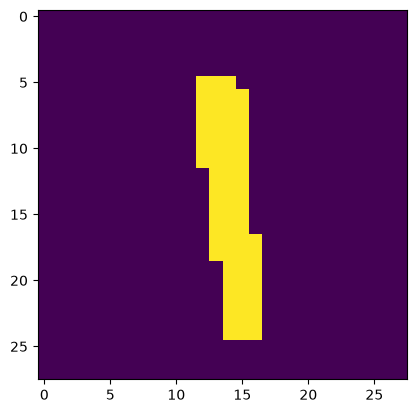

In [29]:
import matplotlib.pyplot as plt

training_data, test_data = load_data_wrapper(50000)
print(training_data[8])
lll8 = np.reshape(training_data[8][0], (28, 28))
plt.imshow(lll8)
plt.show()

Создайте нейронную сеть для распознавания рукописных цифр:


In [30]:
net = Network([784, 30, 10])
""" Вывод результата на экран: """
print('Сеть net:')
print('Количетво слоев:', net.num_layers)
for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])
for i in range(net.num_layers - 1):
    print('W_', i + 1, ':')
    print(np.round(net.weights[i], 2))
    print('b_', i + 1, ':')
    print(np.round(net.biases[i], 2))


Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 30
Количество нейронов в слое 2 : 10
W_ 1 :
[[-0.26 -0.65 -0.76 ... -0.43  0.46 -0.81]
 [-0.67 -0.6   0.94 ... -0.1  -1.27  0.28]
 [-0.93  0.05  1.09 ...  1.14  1.34 -0.24]
 ...
 [-1.58  1.7  -2.2  ...  0.9  -0.02  0.67]
 [ 1.2  -0.33  0.39 ...  0.17 -1.01  0.66]
 [ 0.51 -1.23  0.03 ... -1.36  0.78 -0.01]]
b_ 1 :
[[-0.31]
 [ 0.8 ]
 [-0.31]
 [-0.28]
 [ 0.99]
 [-0.99]
 [ 0.37]
 [ 0.2 ]
 [ 0.51]
 [ 0.31]
 [ 1.61]
 [-0.49]
 [-0.62]
 [ 0.32]
 [-0.47]
 [-0.16]
 [-2.17]
 [-1.62]
 [-1.04]
 [ 0.74]
 [-0.6 ]
 [ 1.94]
 [ 0.02]
 [ 0.21]
 [-2.32]
 [ 0.84]
 [-1.64]
 [-0.47]
 [ 0.31]
 [-0.22]]
W_ 2 :
[[-0.96  0.4  -1.9  -0.31 -1.22  1.09 -0.38 -0.   -0.67  0.04  0.28 -1.78
   2.33 -0.32  1.6   0.63  0.07 -0.12 -0.39  1.68  1.36 -0.01 -0.06  0.23
  -0.46 -0.16  1.42 -0.66  0.15 -0.17]
 [-2.53  1.27 -0.8  -2.14  0.79 -0.26 -0.62 -2.62 -0.02 -0.47  0.54 -0.99
   0.99 -1.05  1.25  1.14  0.72 -0.5   0.34  0.5   

Запустите процедуру обучения созданной нейронной сети, включающую 30 эпох:

In [31]:
import os

MODEL_FILE = 'emnist_model.npz'

if os.path.exists(MODEL_FILE):
    data = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data['weights'])
    net.biases = list(data['biases'])

else:

    net.SGD(
        training_data,
        30,
        10,
        3.0,
        test_data=test_data
    )

    np.savez(
        MODEL_FILE,
        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object)
    )

In [32]:
# net.SGD(training_data, 30, 10, 3.0, test_data=test_data)
#  , training_data # обучающая выборка
#         , epochs # количество эпох обучения
#         , mini_batch_size # размер подвыборки
#         , eta # скорость обучения
#         , test_data # тестирующая выборка

In [33]:
from sklearn.metrics import confusion_matrix, classification_report


# Forward propagate input to a network output
def forward_propagate(net, row):
    inputs = row
    for i in range(net.num_layers - 1):
        new_inputs = []
        for b, w in zip(net.biases[i], net.weights[i]):
            activation = np.dot(w, inputs) + b
            out = net.sigmoid(activation)
            new_inputs.append(out)
        inputs = new_inputs
    return new_inputs


# Make a prediction with a network
def predict(net, row):
    outputs = forward_propagate(net, row)
    return outputs.index(max(outputs))


i = -1
X_train = []
thresholdedData = []

for i in range(len(x_train)):
    row = np.reshape(x_train[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_train.extend(thresholdedData)

for i in range(len(X_train)):
    prediction = predict(net, X_train[i])
    if (i == 0):
        predictTrain = np.array([[prediction]])
    else:
        predictTrain = np.append(predictTrain, [[prediction]], axis=0)

In [34]:
print(confusion_matrix(y_train, predictTrain))
print(classification_report(y_train, predictTrain))

[[5774    5   10   15    5   22   18    4   63    7]
 [   1 6593   29   26   12   13    8   13   38    9]
 [  29   11 5670   32   48   10   22   50   66   20]
 [  35   26   75 5687    6   99   14   58  105   26]
 [  10   15   22    2 5632    2   33   14   19   93]
 [  33   15   26   83   17 5101   51   10   67   18]
 [  26    5    8    3   24   47 5754    1   49    1]
 [  11   15   44   16   32    5    3 6066   16   57]
 [  26   41   30   51   21   41   34   18 5569   20]
 [  34   14    7   91   86   40    4   66   60 5547]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5923
           1       0.98      0.98      0.98      6742
           2       0.96      0.95      0.95      5958
           3       0.95      0.93      0.94      6131
           4       0.96      0.96      0.96      5842
           5       0.95      0.94      0.94      5421
           6       0.97      0.97      0.97      5918
           7       0.96      0.97   

In [35]:
class Network(object):  # используется для описания нейронной сети
    def __init__(self, sizes, alpha=4):  # конструктор класса
        # self – указатель на объект класса
        # sizes – список размеров слоев нейронной сети
        self.alpha = alpha
        self.num_layers = len(sizes)  # задаем количество слоев нейронной сети
        self.sizes = sizes  # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]  # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in
                        zip(sizes[:-1], sizes[1:])]  # задаем случайные начальные веса связей

    def sigmoid(self, z):
        T = 0
        return 1.0 / (1.0 + np.exp(-self.alpha * (z - T)))

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a) + b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta, test_data=None):
        n = len(training_data)

        train_loss_history = []
        valid_loss_history = []

        for j in range(epochs):

            random.shuffle(training_data)

            mini_batches = [
                training_data[k:k + mini_batch_size]
                for k in range(0, n, mini_batch_size)
            ]

            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)

            train_loss = self.total_loss(training_data)
            train_loss_history.append(train_loss)

            if test_data is not None:
                valid_loss = self.total_loss(test_data)
                valid_loss_history.append(valid_loss)

                accuracy = self.evaluate(test_data)

                print(
                    f"Epoch {j + 1}: "
                    f"train loss = {train_loss:.6f}, "
                    f"validation loss = {valid_loss:.6f}, "
                    f"accuracy = {accuracy}/{len(test_data)}"
                )

            else:
                print(
                    f"Epoch {j + 1}: "
                    f"train loss = {train_loss:.6f}"
                )

        return train_loss_history, valid_loss_history

    def update_mini_batch(  # Шаг градиентного спуска
            self  # указатель на объект класса
            , mini_batch  # подвыборка
            , eta  # скорость обучения
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x,
                                                         y)  # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b,
                                                   delta_nabla_b)]  # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w,
                                                   delta_nabla_w)]  # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w - (eta / len(mini_batch)) * nw for w, nw in
                        zip(self.weights, nabla_w)]  # обновляем все веса w нейронной сети
        self.biases = [b - (eta / len(mini_batch)) * nb for b, nb in
                       zip(self.biases, nabla_b)]  # обновляем все смещения b нейронной сети

    def backprop(  # Алгоритм обратного распространения
            self  # указатель на объект класса
            , x  # вектор входных сигналов ,
            , y  # ожидаемый вектор выходных сигналов
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x  # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [
            x]  # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = []  # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b  # считаем активационные потенциалы текущего слоя
            zs.append(z)  # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(
                z)  # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation)  # добавляем элемент (выходные сигналы слоя) в конец списка
        # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(
            zs[-1])  # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta  # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())  # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
            z = zs[-l]  # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
            sp = self.sigmoid_prime(z)  # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
            delta = np.dot(self.weights[-l + 1].transpose(),
                           delta) * sp  # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
            nabla_b[-l] = delta  # градиент dC/db для l-го слоя (BP3)
            nabla_w[-l] = np.dot(delta, activations[-l - 1].transpose())  # градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        test_results = [
            (np.argmax(self.feedforward(x)), np.argmax(y))
            for (x, y) in test_data
        ]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations,
                        y):  # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
        return (output_activations - y)

    def sigmoid_prime(self, z):  # Производная сигмоидальной функции
        return self.alpha * self.sigmoid(z) * (1 - self.sigmoid(z))

    def total_loss(self, data):
        total = 0.0

        for x, y in data:
            output = self.feedforward(x)

            # MSE
            total += np.sum((output - y) ** 2) / 2

        return total / len(data)

In [36]:
data = np.load('emnist_k_to_t_one.npz')

X_train = data['X_train']
y_train_onehot = data['y_train']

X_test = data['X_test']
y_test_onehot = data['y_test']

y_train = np.argmax(y_train_onehot, axis=1)
y_test = np.argmax(y_test_onehot, axis=1)

from sklearn.model_selection import train_test_split

X_train, X_val, y_train_onehot, y_val_onehot = train_test_split(
    X_train,
    y_train_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

y_train = np.argmax(y_train_onehot, axis=1)
y_val = np.argmax(y_val_onehot, axis=1)

X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

training_inputs = [
    np.reshape(x, (784, 1))
    for x in X_train
]

training_results = [
    np.reshape(y, (10, 1))
    for y in y_train_onehot
]

training_data = list(
    zip(training_inputs, training_results)
)

validation_inputs = [
    np.reshape(x, (784, 1))
    for x in X_val
]

validation_results = [
    np.reshape(y, (10, 1))
    for y in y_val_onehot
]

validation_data = list(
    zip(validation_inputs, validation_results)
)

test_inputs = [
    np.reshape(x, (784, 1))
    for x in X_test
]

test_data = list(
    zip(test_inputs, y_test)
)

net = Network([784, 70, 10])

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])

MODEL_FILE = 'litters_model_alpha4.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

Confusion matrix:
[[145   3   4   0   0   4   0   0   4   0]
 [  4 156   0   0   0   0   0   0   0   0]
 [  0   0 152   0   0   6   0   2   0   0]
 [ 10   0  35   9   0  50   0  44  12   0]
 [ 15   0   9   8   0  20   0  18  90   0]
 [  4   3   2   0   0 139   0   3   8   1]
 [ 39   8   9   5   1  32   0   1  64   1]
 [  7   1   0   0   0   6   0 143   3   0]
 [  7   0   1   1   0   1   0   0 150   0]
 [ 31  46  14   3   1  20   2  13  29   1]]

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.91      0.69       160
           1       0.72      0.97      0.83       160
           2       0.67      0.95      0.79       160
           3       0.35      0.06      0.10       160
           4       0.00      0.00      0.00       160
           5       0.50      0.87      0.63       160
           6   

C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

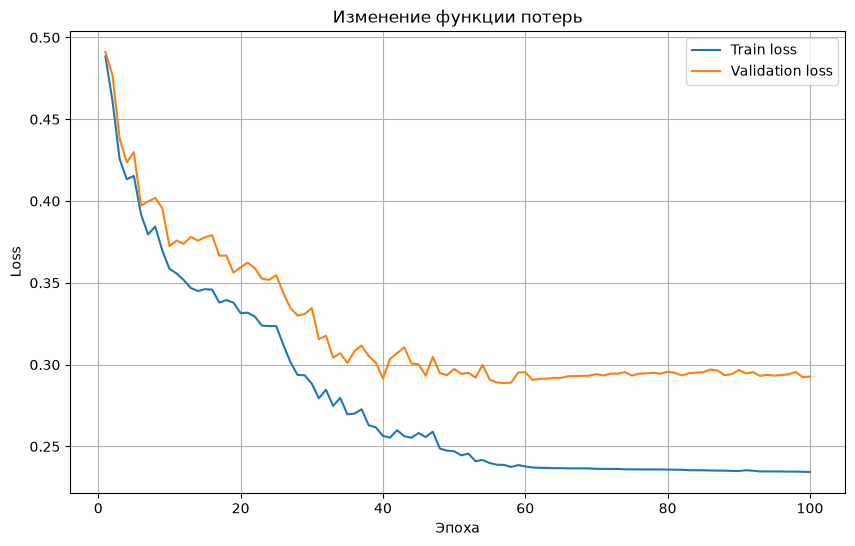

In [37]:
import matplotlib.pyplot as plt


def graphic():
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        train_loss,
        label='Train loss'
    )

    plt.plot(
        epochs,
        valid_loss,
        label='Validation loss'
    )

    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.title('Изменение функции потерь')
    plt.legend()
    plt.grid()
    plt.show()


graphic()


Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

In [38]:
net = Network([784, 70, 10], alpha=3.5)

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])

MODEL_FILE = 'litters_model_alpha35.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

Confusion matrix:
[[145   5   0   1   5   2   1   0   0   1]
 [  8 152   0   0   0   0   0   0   0   0]
 [ 31   8   0   4  36  45   1   2  10  23]
 [ 50   5   0   5  47  31  12   1   2   7]
 [  4   0   0   1 153   2   0   0   0   0]
 [  1   2   0   0   1 156   0   0   0   0]
 [ 45  27   0   1  17  61   4   0   1   4]
 [ 52   9   0   1  26  62   1   0   1   8]
 [ 43  14   0   2  49  23   8   6   1  14]
 [ 44  62   0   0  11  39   2   0   0   2]]

Classification report:
              precision    recall  f1-score   support

           0       0.34      0.91      0.50       160
           1       0.54      0.95      0.68       160
           2       0.00      0.00      0.00       160
           3       0.33      0.03      0.06       160
           4       0.44      0.96      0.61       160
           5       0.37      0.97      0.54       160
           6   

C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

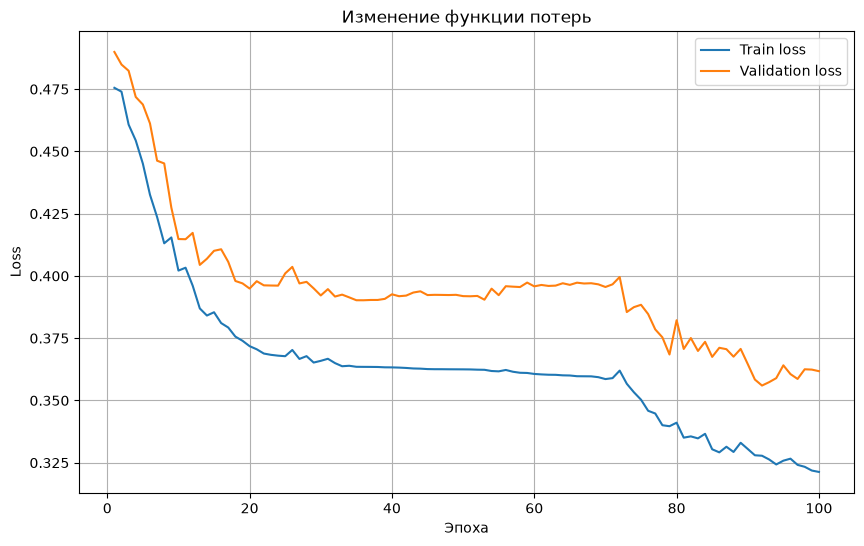

In [39]:
graphic()

In [40]:
net = Network([784, 70, 10], alpha=4.5)

print('Сеть net:')
print('Количетво слоев:', net.num_layers)

for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])

MODEL_FILE = 'litters_model_alpha45.npz'

if os.path.exists(MODEL_FILE):
    data_model = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data_model['weights'])
    net.biases = list(data_model['biases'])

    train_loss = data_model['train_loss']
    valid_loss = data_model['valid_loss']

else:
    epochs_count = 100
    batch_size = 50
    learning_rate = 3.0

    train_loss, valid_loss = net.SGD(
        training_data,
        epochs_count,
        batch_size,
        learning_rate,
        test_data=validation_data
    )

    np.savez(
        MODEL_FILE,

        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object),

        sizes=np.array(net.sizes),
        alpha=np.array(net.alpha),

        epochs=np.array(epochs_count),
        batch_size=np.array(batch_size),
        eta=np.array(learning_rate),

        train_loss=np.array(train_loss),
        valid_loss=np.array(valid_loss)
    )


def predict(net, row):
    row = np.reshape(row, (784, 1))
    output = net.feedforward(row)

    return np.argmax(output)


predictTrain = np.array([
    predict(net, x)
    for x in X_train
])

print("\nConfusion matrix:")
print(confusion_matrix(y_train, predictTrain))

print("\nClassification report:")
print(classification_report(y_train, predictTrain))

predictVal = np.array([
    predict(net, x)
    for x in X_val
])

print("\nConfusion matrix (validation):")
print(confusion_matrix(y_val, predictVal))

print("\nClassification report (validation):")
print(classification_report(y_val, predictVal))

predictTest = np.array([
    predict(net, x)
    for x in X_test
])

print("\nConfusion matrix (test):")
print(confusion_matrix(y_test, predictTest))

print("\nClassification report (test):")
print(classification_report(y_test, predictTest))

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 70
Количество нейронов в слое 2 : 10

Confusion matrix:
[[ 10   9  24  40   6   1  48   2   5  15]
 [ 42   1  21   0  14   4  74   0   2   2]
 [  0   0 152   5   0   0   3   0   0   0]
 [  0   0   7 151   0   0   2   0   0   0]
 [ 10   0   6 116   0   0  21   0   0   7]
 [  2   4   2  61   6   0  71   0   1  13]
 [  6   1   4   4   0   0 144   0   0   1]
 [  3   6   9 107   1   0  13   4   0  17]
 [ 15   3   6  42   2   1  78   3   0  10]
 [  4   2  31  23  14   1  71   2   8   4]]

Classification report:
              precision    recall  f1-score   support

           0       0.11      0.06      0.08       160
           1       0.04      0.01      0.01       160
           2       0.58      0.95      0.72       160
           3       0.28      0.94      0.43       160
           4       0.00      0.00      0.00       160
           5       0.00      0.00      0.00       160
           6   

C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\admin\PycharmProjects\network2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

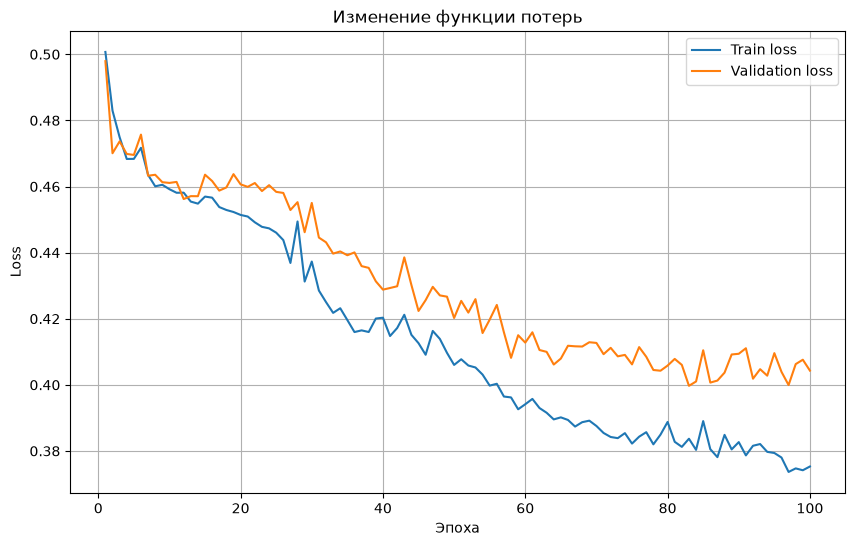

In [41]:
graphic()

In [42]:
import torch
import torch.nn as nn
import plotly.graph_objects as go
import torch.optim as optim


class Network(nn.Module):
    def __init__(self, sizes, alpha=4, dropout=0.2):
        super().__init__()

        self.alpha = alpha

        layers = []

        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            layers.append(CustomSigmoid(alpha))
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(sizes[-2], sizes[-1]))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

    def predict(self, x):
        logits = self.forward(x)
        return torch.softmax(logits, dim=1)


class CustomSigmoid(nn.Module):
    def __init__(self, alpha=4):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return torch.sigmoid(self.alpha * x)


class NetworkWork():

    def __init__(self, model_torch, criterion, optimizer, max_epochs, patience, X_train_torch, y_train_torch):
        self.model_torch = model_torch
        self.criterion = criterion
        self.optimizer = optimizer
        self.max_epochs = max_epochs
        self.patience = patience
        self.X_train_torch = X_train_torch
        self.y_train_torch = y_train_torch
        self.train_losses = []
        self.val_losses = []

    def early_stopping(self):

        X_train_torch_part, X_val_torch, \
        y_train_torch_part, y_val_torch = train_test_split(
            self.X_train_torch,
            self.y_train_torch,
            test_size=0.2,
            random_state=42,
            stratify=self.y_train_torch
        )

        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                X_train_torch_part,
                y_train_torch_part
            ),
            batch_size=32,
            shuffle=True
        )

        best_val_loss = float('inf')
        best_model = None
        epochs_without_improvement = 0

        for epoch in range(self.max_epochs):
            # Обучение
            self.model_torch.train()

            epoch_loss = 0.0

            for X_batch, y_batch in train_loader:

                self.optimizer.zero_grad()

                if self.criterion.__class__.__name__ == 'CrossEntropyLoss':
                    output = self.model_torch(X_batch)

                    loss = self.criterion(
                        output,
                        y_batch
                    )
                else:
                    output = torch.softmax(
                        self.model_torch(X_batch),
                        dim=1
                    )
                    loss = self.criterion(
                        output,
                        y_batch
                    )
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()

            train_loss = epoch_loss / len(train_loader)
            self.train_losses.append(train_loss)

            # Валидация
            self.model_torch.eval()

            with torch.no_grad():

                if self.criterion.__class__.__name__ == 'CrossEntropyLoss':
                    val_output = self.model_torch(X_val_torch)

                    val_loss = self.criterion(
                        val_output,
                        y_val_torch
                    )
                else:
                    val_output = torch.softmax(
                        self.model_torch(X_val_torch),
                        dim=1
                    )
                    val_loss = self.criterion(
                        val_output,
                        y_val_torch
                    )
            val_loss = val_loss.item()

            self.val_losses.append(val_loss)

            # Early Stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = {
                    key: value.clone()
                    for key, value in self.model_torch.state_dict().items()
                }
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.patience:
                print("Early stopping на эпохе:",epoch + 1)
                break
        self.model_torch.load_state_dict(best_model)

    def output_info(self):
        best_epoch = np.argmin(self.val_losses)

        print("Оптимальная эпоха:", best_epoch + 1)
        print("Минимальный Validation Loss:", self.val_losses[best_epoch])
        print("Train Loss в оптимальной точке:", self.train_losses[best_epoch])

        print("Количество эпох обучения:", len(self.train_losses))

        last_n = min(20, len(self.train_losses))

        print(f"\nПоследние {last_n} эпох:")
        print("Эпоха | Train Loss | Validation Loss")
        print("-" * 40)

        for i in range(len(self.train_losses) - last_n, len(self.train_losses)):
            print(
                f"{i + 1:5d} | "
                f"{self.train_losses[i]:10.6f} | "
                f"{self.val_losses[i]:15.6f}"
            )

    def print_graphic(self, title):
        fig = go.Figure()

        fig.add_trace(
            go.Scatter(
                y=self.train_losses,
                mode='lines',
                name='Обучающая выборка'
            )
        )

        fig.add_trace(
            go.Scatter(
                y=self.val_losses,
                mode='lines',
                name='Валидационная выборка'
            )
        )

        fig.update_layout(
            title=title,
            xaxis_title='Эпоха',
            yaxis_title='Loss'
        )

        fig.show()

    def print_confusion(self, y_train, y_test, pred_train_torch, pred_test_torch):
        print("Матрица ошибок — PyTorch MLP — Train:")
        print(confusion_matrix(y_train, pred_train_torch))

        print("\nClassification Report — PyTorch MLP — Train:")
        print(classification_report(y_train, pred_train_torch))

        print("\nМатрица ошибок — PyTorch MLP — Test:")
        print(confusion_matrix(y_test, pred_test_torch))

        print("\nClassification Report — PyTorch MLP — Test:")
        print(classification_report(y_test, pred_test_torch))

    def save_work(self, MODEL_FILE):
        torch.save({
            'model_state': self.model_torch.state_dict(),

            'train_losses': self.train_losses,
            'val_losses': self.val_losses,

            'max_epochs': self.max_epochs,
            'patience': self.patience,

            'criterion': self.criterion.__class__.__name__,
            'optimizer': self.optimizer.__class__.__name__

        }, MODEL_FILE)

    def work(self, MODEL_FILE, X_test_torch, y_train, y_test):
        if self.load_save(MODEL_FILE):
            print("Модель загружена из файла.")
        else:
            self.early_stopping()
            self.save_work(MODEL_FILE)
            print("Модель обучена и сохранена.")

        self.output_info()
        self.print_graphic(MODEL_FILE)

        self.model_torch.eval()

        with torch.no_grad():

            pred_train_torch = torch.argmax(
                self.model_torch(self.X_train_torch),
                dim=1
            ).cpu().numpy()

            pred_test_torch = torch.argmax(
                self.model_torch(X_test_torch),
                dim=1
            ).cpu().numpy()

        self.print_confusion(
            y_train,
            y_test,
            pred_train_torch,
            pred_test_torch
        )

    def load_save(self, MODEL_FILE):
        if os.path.exists(MODEL_FILE):

            data_model = torch.load(
                MODEL_FILE,
                weights_only=False
            )

            self.model_torch.load_state_dict(
                data_model['model_state']
            )

            self.train_losses = data_model['train_losses']
            self.val_losses = data_model['val_losses']
            return True

        return False


In [43]:
X_train_torch = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_torch = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_torch = torch.tensor(
    X_test,
    dtype=torch.float32
)

# Метки классов для CrossEntropyLoss
y_train_torch = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_torch = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_torch = torch.tensor(
    y_test,
    dtype=torch.long
)

# One-hot метки для MSELoss
y_train_mse_torch = torch.tensor(
    y_train_onehot,
    dtype=torch.float32
)

y_val_mse_torch = torch.tensor(
    y_val_onehot,
    dtype=torch.float32
)

In [44]:
MODEL_FILE = 'CEAdam.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=100,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 23
Минимальный Validation Loss: 0.46214455366134644
Train Loss в оптимальной точке: 0.1833857089281082
Количество эпох обучения: 43

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
   24 |   0.171987 |        0.469526
   25 |   0.160895 |        0.482879
   26 |   0.161783 |        0.463195
   27 |   0.148172 |        0.463961
   28 |   0.133945 |        0.468713
   29 |   0.140597 |        0.471581
   30 |   0.137255 |        0.484971
   31 |   0.130609 |        0.466007
   32 |   0.124111 |        0.473087
   33 |   0.120308 |        0.472084
   34 |   0.115242 |        0.469886
   35 |   0.109936 |        0.466098
   36 |   0.102203 |        0.474599
   37 |   0.098536 |        0.480414
   38 |   0.090822 |        0.466599
   39 |   0.100979 |        0.478370
   40 |   0.088507 |        0.487284
   41 |   0.088136 |        0.472860
   42 |   0.084655 |        0.478047
   43 |   0.079386 | 

Матрица ошибок — PyTorch MLP — Train:
[[156   1   0   2   0   0   0   1   0   0]
 [  1 158   0   0   0   0   1   0   0   0]
 [  0   0 156   4   0   0   0   0   0   0]
 [  1   0   3 156   0   0   0   0   0   0]
 [  0   0   0   1 157   0   1   1   0   0]
 [  0   0   0   1   2 152   0   2   0   3]
 [  2   2   2   1   2   0 148   0   0   3]
 [  0   1   0   1   0   2   2 151   0   3]
 [  0   0   1   0   2   0   3   0 154   0]
 [  1   4   0   0   0   1   2   5   4 143]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       160
           1       0.95      0.99      0.97       160
           2       0.96      0.97      0.97       160
           3       0.94      0.97      0.96       160
           4       0.96      0.98      0.97       160
           5       0.98      0.95      0.97       160
           6       0.94      0.93      0.93       160
           7       0.94      0.94      0.94       16

In [45]:
MODEL_FILE = 'MSEAdam.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.Adam(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=100,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 100
Минимальный Validation Loss: 0.026278646662831306
Train Loss в оптимальной точке: 0.018295221030712128
Количество эпох обучения: 100

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
   81 |   0.023149 |        0.028572
   82 |   0.022675 |        0.028423
   83 |   0.022520 |        0.028277
   84 |   0.022314 |        0.028143
   85 |   0.022584 |        0.028006
   86 |   0.021819 |        0.027872
   87 |   0.021598 |        0.027737
   88 |   0.021207 |        0.027596
   89 |   0.020799 |        0.027462
   90 |   0.021111 |        0.027319
   91 |   0.020882 |        0.027187
   92 |   0.020100 |        0.027065
   93 |   0.020736 |        0.026943
   94 |   0.020244 |        0.026832
   95 |   0.019758 |        0.026732
   96 |   0.019533 |        0.026628
   97 |   0.019633 |        0.026533
   98 |   0.019553 |        0.026444
   99 |   0.019104 |        0.026360
  100 |   0.0182

Матрица ошибок — PyTorch MLP — Train:
[[145   1   1   3   0   0   2   4   1   3]
 [  3 156   0   0   0   0   1   0   0   0]
 [  0   0 154   4   1   1   0   0   0   0]
 [  3   0   7 145   1   1   1   1   1   0]
 [  0   0   6   1 149   1   1   0   2   0]
 [  0   2   0   1   2 148   2   1   0   4]
 [  1   4   1   0   2   0 142   0   6   4]
 [  1   1   2   1   0  10   1 141   1   2]
 [  0   2   1   0   3   1   7   0 146   0]
 [  3  14   0   0   2   3   4   5   6 123]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       160
           1       0.87      0.97      0.92       160
           2       0.90      0.96      0.93       160
           3       0.94      0.91      0.92       160
           4       0.93      0.93      0.93       160
           5       0.90      0.93      0.91       160
           6       0.88      0.89      0.88       160
           7       0.93      0.88      0.90       16

In [46]:
MODEL_FILE = 'CESGD.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Модель загружена из файла.
Оптимальная эпоха: 500
Минимальный Validation Loss: 0.612585186958313
Train Loss в оптимальной точке: 0.545355012267828
Количество эпох обучения: 500

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  481 |   0.550107 |        0.620985
  482 |   0.549439 |        0.620662
  483 |   0.554929 |        0.620162
  484 |   0.555656 |        0.619833
  485 |   0.541932 |        0.619394
  486 |   0.545167 |        0.619113
  487 |   0.555386 |        0.618629
  488 |   0.542562 |        0.618170
  489 |   0.545101 |        0.617766
  490 |   0.543628 |        0.617161
  491 |   0.534241 |        0.616817
  492 |   0.551523 |        0.616240
  493 |   0.539124 |        0.615944
  494 |   0.543035 |        0.615461
  495 |   0.543912 |        0.614920
  496 |   0.540806 |        0.614381
  497 |   0.541859 |        0.613971
  498 |   0.546129 |        0.613673
  499 |   0.534685 |        0.613126
  500 |   0.545355 |  

Матрица ошибок — PyTorch MLP — Train:
[[143   3   1   2   0   1   0   3   5   2]
 [  4 150   0   0   0   0   3   0   0   3]
 [  0   0 153   6   1   0   0   0   0   0]
 [  3   0   8 143   1   2   1   1   1   0]
 [  1   0   4   1 148   1   2   1   2   0]
 [  0   3   0   1   4 139   3   6   0   4]
 [  2   7   2   0   3   1 132   0   7   6]
 [  3   1   1   2   0   6   2 143   0   2]
 [  1   2   1   0   3   0   6   0 147   0]
 [  6  20   0   0   1   4   8   7   5 109]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       160
           1       0.81      0.94      0.87       160
           2       0.90      0.96      0.93       160
           3       0.92      0.89      0.91       160
           4       0.92      0.93      0.92       160
           5       0.90      0.87      0.89       160
           6       0.84      0.82      0.83       160
           7       0.89      0.89      0.89       16

In [47]:
MODEL_FILE = 'MSESGD.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.1
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель загружена из файла.
Оптимальная эпоха: 374
Минимальный Validation Loss: 0.020470552146434784
Train Loss в оптимальной точке: 0.010663293220568448
Количество эпох обучения: 394

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  375 |   0.010063 |        0.020525
  376 |   0.010295 |        0.020496
  377 |   0.010247 |        0.020490
  378 |   0.010214 |        0.020527
  379 |   0.010277 |        0.020504
  380 |   0.010575 |        0.020562
  381 |   0.009682 |        0.020585
  382 |   0.010122 |        0.020540
  383 |   0.009680 |        0.020587
  384 |   0.010106 |        0.020642
  385 |   0.009526 |        0.020620
  386 |   0.010193 |        0.020602
  387 |   0.010007 |        0.020539
  388 |   0.010259 |        0.020560
  389 |   0.009880 |        0.020563
  390 |   0.010345 |        0.020531
  391 |   0.010633 |        0.020565
  392 |   0.009838 |        0.020510
  393 |   0.009763 |        0.020544
  394 |   0.0100

Матрица ошибок — PyTorch MLP — Train:
[[148   1   0   3   0   1   1   5   1   0]
 [  2 156   0   0   0   0   1   1   0   0]
 [  0   0 154   5   1   0   0   0   0   0]
 [  1   0   4 152   1   1   0   0   1   0]
 [  1   0   2   0 152   1   1   2   1   0]
 [  0   1   0   0   1 154   2   1   0   1]
 [  0   2   0   1   1   0 149   0   4   3]
 [  0   0   0   2   0   5   1 145   2   5]
 [  0   0   1   0   3   1   3   0 152   0]
 [  3   4   0   0   1   3   2   4   4 139]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       160
           1       0.95      0.97      0.96       160
           2       0.96      0.96      0.96       160
           3       0.93      0.95      0.94       160
           4       0.95      0.95      0.95       160
           5       0.93      0.96      0.94       160
           6       0.93      0.93      0.93       160
           7       0.92      0.91      0.91       16

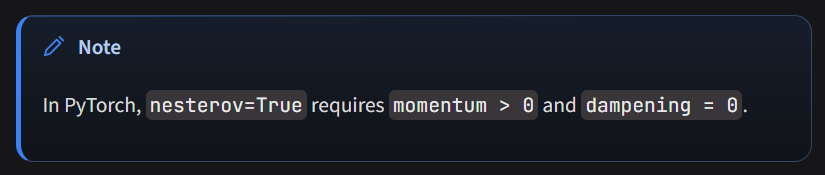

Источник:https://deeplearningnotes.com/neural-networks/gradient-descent/nesterov-momentum

In [50]:
MODEL_FILE = 'CESGD_nesterov.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4,
        dampening=0.0,
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)


Early stopping на эпохе: 258
Модель обучена и сохранена.
Оптимальная эпоха: 238
Минимальный Validation Loss: 0.47600802779197693
Train Loss в оптимальной точке: 0.18561719348654152
Количество эпох обучения: 258

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  239 |   0.182055 |        0.476996
  240 |   0.189343 |        0.476487
  241 |   0.178393 |        0.479386
  242 |   0.165913 |        0.477644
  243 |   0.189278 |        0.479268
  244 |   0.175595 |        0.478854
  245 |   0.180574 |        0.477692
  246 |   0.171950 |        0.481156
  247 |   0.178453 |        0.479648
  248 |   0.173223 |        0.478080
  249 |   0.165245 |        0.477518
  250 |   0.181367 |        0.479313
  251 |   0.165687 |        0.478067
  252 |   0.180320 |        0.480536
  253 |   0.172003 |        0.479737
  254 |   0.168032 |        0.479760
  255 |   0.174244 |        0.480940
  256 |   0.165956 |        0.476507
  257 |   0.172161 |     

Матрица ошибок — PyTorch MLP — Train:
[[154   1   0   3   0   0   0   1   0   1]
 [  2 157   0   0   0   0   1   0   0   0]
 [  0   0 156   4   0   0   0   0   0   0]
 [  1   0   4 155   0   0   0   0   0   0]
 [  0   0   0   2 156   0   1   1   0   0]
 [  0   0   0   2   1 154   0   0   0   3]
 [  1   2   1   1   2   0 148   0   2   3]
 [  1   0   0   1   0   5   1 148   2   2]
 [  1   0   1   1   1   0   0   0 156   0]
 [  1   5   0   0   0   2   2   3   4 143]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       160
           1       0.95      0.98      0.97       160
           2       0.96      0.97      0.97       160
           3       0.92      0.97      0.94       160
           4       0.97      0.97      0.97       160
           5       0.96      0.96      0.96       160
           6       0.97      0.93      0.95       160
           7       0.97      0.93      0.95       16

In [48]:
MODEL_FILE = 'MSESGD_nesterov.pth'

net = Network([784, 70, 10])

work = NetworkWork(
    model_torch=net,
    criterion=nn.MSELoss(),
    optimizer=optim.SGD(
        net.parameters(),
        lr=0.001,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4,
        dampening=0.0,
    ),
    max_epochs=500,
    patience=20,
    X_train_torch=X_train_torch,
    y_train_torch=y_train_mse_torch
)

work.work(
    MODEL_FILE=MODEL_FILE,
    X_test_torch=X_test_torch,
    y_train=y_train,
    y_test=y_test
)

Модель обучена и сохранена.
Оптимальная эпоха: 500
Минимальный Validation Loss: 0.04240177944302559
Train Loss в оптимальной точке: 0.04218429415486753
Количество эпох обучения: 500

Последние 20 эпох:
Эпоха | Train Loss | Validation Loss
----------------------------------------
  481 |   0.043687 |        0.043580
  482 |   0.042672 |        0.043518
  483 |   0.043422 |        0.043455
  484 |   0.042511 |        0.043390
  485 |   0.042572 |        0.043326
  486 |   0.042631 |        0.043267
  487 |   0.042644 |        0.043206
  488 |   0.042515 |        0.043142
  489 |   0.042838 |        0.043079
  490 |   0.042135 |        0.043018
  491 |   0.042159 |        0.042953
  492 |   0.042111 |        0.042892
  493 |   0.041718 |        0.042829
  494 |   0.042094 |        0.042767
  495 |   0.042160 |        0.042709
  496 |   0.042076 |        0.042646
  497 |   0.042043 |        0.042586
  498 |   0.041965 |        0.042526
  499 |   0.041863 |        0.042462
  500 |   0.04218

Матрица ошибок — PyTorch MLP — Train:
[[141   6   1   2   1   1   0   4   4   0]
 [  3 154   0   0   0   0   2   1   0   0]
 [  0   0 152   7   1   0   0   0   0   0]
 [  3   1  16 132   4   1   0   2   1   0]
 [  1   0   5   4 143   3   2   0   2   0]
 [  1   4   1   1   2 133   5  13   0   0]
 [  8  18   2   4   4   3 108   0  11   2]
 [  3   3   6   1   0  12   2 133   0   0]
 [  1   1   1   1   2   0   4   0 150   0]
 [  8  75   7   0   1  13  11  14  10  21]]

Classification Report — PyTorch MLP — Train:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       160
           1       0.59      0.96      0.73       160
           2       0.80      0.95      0.87       160
           3       0.87      0.82      0.85       160
           4       0.91      0.89      0.90       160
           5       0.80      0.83      0.82       160
           6       0.81      0.68      0.73       160
           7       0.80      0.83      0.81       16

выводить формулы оптимизации, активации, обновления весовых коэффициентов на каждой батче.


сверточные сети самые простые, обучить на буквах на пайторч
выходная функция поэкспериментировать с разными функциями при разных оптимизаторах

поработать с разными сгд из пдф https://el.istu.edu/pluginfile.php/631909/mod_resource/content/4/%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D0%B8%20%D0%BF%D0%BE%D1%82%D0%B5%D1%80%D1%8C%20%D0%B8%20%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D0%BA%D0%B8%20%D0%B2%D0%B5%D1%80%D1%81%D0%B8%D1%8F%202025.pdf


градиенты на предыдущих шагах изучить адам (источник внести) адам сохраняет предыдущие сколько шагов и шаг (батч, эпоха)

ВОТ ТАК ВЫВОДИТЬ:
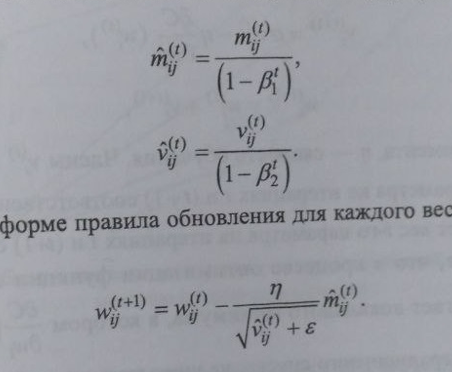